# Week 3-1 ? MMT-01 ? Execution Strategy I

This notebook consolidates the runnable pieces of the lecture and the official in-class workbook. It uses local CSV files in this folder, transcribed from the official Excel workbook, so every path is relative and the notebook can be run offline.

The course pack does not include real tick-by-tick order-event data. The order-flow imbalance section uses a deterministic simulated event stream, clearly labelled as a proxy, to demonstrate the official reading's calculation.

## Configuration and imports

Edit the file names below if you replace the lecture CSVs with another order book or trade tape that has the same column structure.

In [1]:
# EDIT HERE to use another compatible dataset in this same folder.
ORDERBOOK_CSV = "mmt01_orderbook_abc.csv"
DEPTH_CSV = "mmt01_depth_structure.csv"
VWAP_CSV = "mmt01_vwap_trades.csv"
PRO_RATA_CSV = "mmt01_pro_rata_sell_10.csv"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

DATA_DIR = Path(".")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
np.random.seed(7)

## Part 1 ? Load the official workbook data

The order book table is the lecture's ABC example: bid quantities and prices on the left, ask prices and quantities on the right. The best bid is the highest bid; the best ask is the lowest ask.

In [2]:
orderbook = pd.read_csv(DATA_DIR / ORDERBOOK_CSV)
depth_book = pd.read_csv(DATA_DIR / DEPTH_CSV)
vwap_trades = pd.read_csv(DATA_DIR / VWAP_CSV)
pro_rata = pd.read_csv(DATA_DIR / PRO_RATA_CSV)

best_bid = orderbook.loc[0, "bid_price"]
best_ask = orderbook.loc[0, "ask_price"]
spread = best_ask - best_bid
mid = (best_bid + best_ask) / 2
spread_bps = spread / mid * 10_000

print(f"Best bid: {best_bid:.2f}")
print(f"Best ask: {best_ask:.2f}")
print(f"Spread: {spread:.2f} = {spread_bps:.1f} basis points")
print(f"Mid-price: {mid:.2f}")
display(orderbook)

Best bid: 100.00
Best ask: 100.50
Spread: 0.50 = 49.9 basis points
Mid-price: 100.25


,level,bid_qty,bid_price,ask_price,ask_qty
0,1,5,100.00,100.5,15
1,2,3,99.50,101.0,35
2,3,10,99.00,101.5,5
3,4,20,98.25,102.5,2
4,5,5,98.00,103.0,15


## Part 2 ? Visualize order-book depth

Depth is the quantity available at each price level. The official notes point out that the book is often thin near the inside and deeper a few ticks away; that is why large market orders can move the quote.

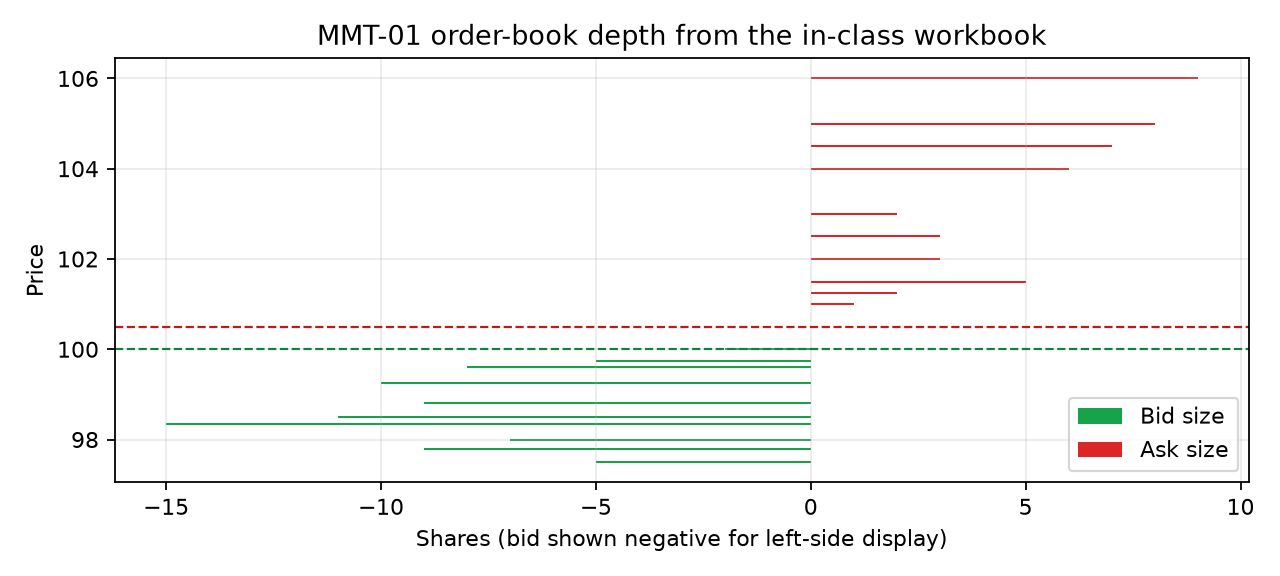

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(depth_book["bid_price"], -depth_book["bid_qty"], height=0.045, color="#16a34a", label="Bid size")
ax.barh(depth_book["ask_price"], depth_book["ask_qty"], height=0.045, color="#dc2626", label="Ask size")
ax.axhline(best_bid, color="#15803d", linestyle="--", linewidth=1)
ax.axhline(best_ask, color="#b91c1c", linestyle="--", linewidth=1)
ax.set_title("MMT-01 order-book depth from the in-class workbook")
ax.set_xlabel("Shares (bid shown negative for left-side display)")
ax.set_ylabel("Price")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig("chart_addendum_1_orderbook_depth.png", dpi=160)
plt.close(fig)
display(Image(filename="chart_addendum_1_orderbook_depth.png"))

## Part 3 ? Market orders walk the book

A market order demands immediacy. The next cell fills a market buy against the ask side, level by level, and computes the average fill price. This reproduces the key lecture warning: the quote is not one price; it is a ladder.

In [4]:
def walk_book_buy(quantity, book):
    remaining = quantity
    rows = []
    for _, row in book.iterrows():
        take = min(remaining, int(row["ask_qty"]))
        if take > 0:
            rows.append({"ask_price": row["ask_price"], "shares": take, "cost": take * row["ask_price"]})
            remaining -= take
        if remaining == 0:
            break
    fills = pd.DataFrame(rows)
    avg_price = fills["cost"].sum() / fills["shares"].sum()
    return fills, remaining, avg_price

fills_20, rem_20, avg_20 = walk_book_buy(20, orderbook)
fills_400, rem_400, avg_400 = walk_book_buy(400, pd.DataFrame({
    "ask_price": [50.10, 50.15, 50.20],
    "ask_qty": [100, 700, 1000],
}))

print("Workbook-style market buy for 20 shares:")
display(fills_20)
print(f"Average fill = {avg_20:.4f}; remaining = {rem_20}")

print("\nCore example market buy for 400 shares:")
display(fills_400)
print(f"Average fill = {avg_400:.4f}; slippage vs best ask 50.10 = {avg_400 - 50.10:.4f}")

Workbook-style market buy for 20 shares:


,ask_price,shares,cost
0,100.5,15,1507.5
1,101.0,5,505.0


Average fill = 100.6250; remaining = 0

Core example market buy for 400 shares:


,ask_price,shares,cost
0,50.10,100,5010.0
1,50.15,300,15045.0


Average fill = 50.1375; slippage vs best ask 50.10 = 0.0375


## Part 4 ? Marketable limit order versus market order

The workbook contrasts a marketable buy-limit with a plain market buy. Both can fill immediately, but the limit order has a price ceiling and may leave a residual resting order.

In [5]:
limit_price = 100.75
marketable_limit_qty = 20
ask1_price, ask1_qty = 100.50, 15
ask2_price, ask2_qty = 101.00, 35

limit_fill_first = min(marketable_limit_qty, ask1_qty)
limit_remaining = marketable_limit_qty - limit_fill_first
market_rows = pd.DataFrame([
    {"method": "Marketable buy-limit @100.75", "fill_price": ask1_price, "shares": limit_fill_first, "resting_bid_after": limit_remaining},
    {"method": "Plain market buy", "fill_price": ask1_price, "shares": 15, "resting_bid_after": 0},
    {"method": "Plain market buy", "fill_price": ask2_price, "shares": 5, "resting_bid_after": 0},
])
print("The marketable limit fills 15 at 100.50 and leaves 5 as a bid at 100.75.")
print("The market order fills all 20, including 5 shares at the next ask, 101.00.")
display(market_rows)

The marketable limit fills 15 at 100.50 and leaves 5 as a bid at 100.75.
The market order fills all 20, including 5 shares at the next ask, 101.00.


,method,fill_price,shares,resting_bid_after
0,Marketable buy-limit @100.75,100.5,15,5
1,Plain market buy,100.5,15,0
2,Plain market buy,101.0,5,0


## Part 5 ? Price-time priority queue math

The workbook's price-time sheet shows that when you join an existing price level, the older quantity at that price has priority. This is queue position, not just price.

In [6]:
existing_qty = 3
your_qty = 10
incoming_sell_qty = 8
existing_fill = min(existing_qty, incoming_sell_qty)
your_fill = min(your_qty, max(0, incoming_sell_qty - existing_fill))
queue_after = pd.DataFrame([
    {"owner": "Existing order at 99.50", "starting_qty": existing_qty, "filled": existing_fill, "remaining": existing_qty - existing_fill},
    {"owner": "Your later order at 99.50", "starting_qty": your_qty, "filled": your_fill, "remaining": your_qty - your_fill},
])
print("Sell order size = 8. Existing quantity fills first because it reached the queue first.")
display(queue_after)

Sell order size = 8. Existing quantity fills first because it reached the queue first.


,owner,starting_qty,filled,remaining
0,Existing order at 99.50,3,3,0
1,Your later order at 99.50,10,5,5


## Part 6 ? VWAP from the official Excel numbers

Volume-Weighted Average Price (VWAP) is the execution report card. The workbook gives four trades; we calculate price x volume, cumulative VWAP, and a small chart.

VWAP = sum(price x volume) / sum(volume) = 14.205


,trade,price,volume,price_x_volume,cum_price_x_volume,cum_volume,cum_vwap
0,1,14.00,1100,15400.0,15400.0,1100,14.000000
1,2,14.50,600,8700.0,24100.0,1700,14.176471
2,3,14.20,1800,25560.0,49660.0,3500,14.188571
3,4,14.35,400,5740.0,55400.0,3900,14.205128


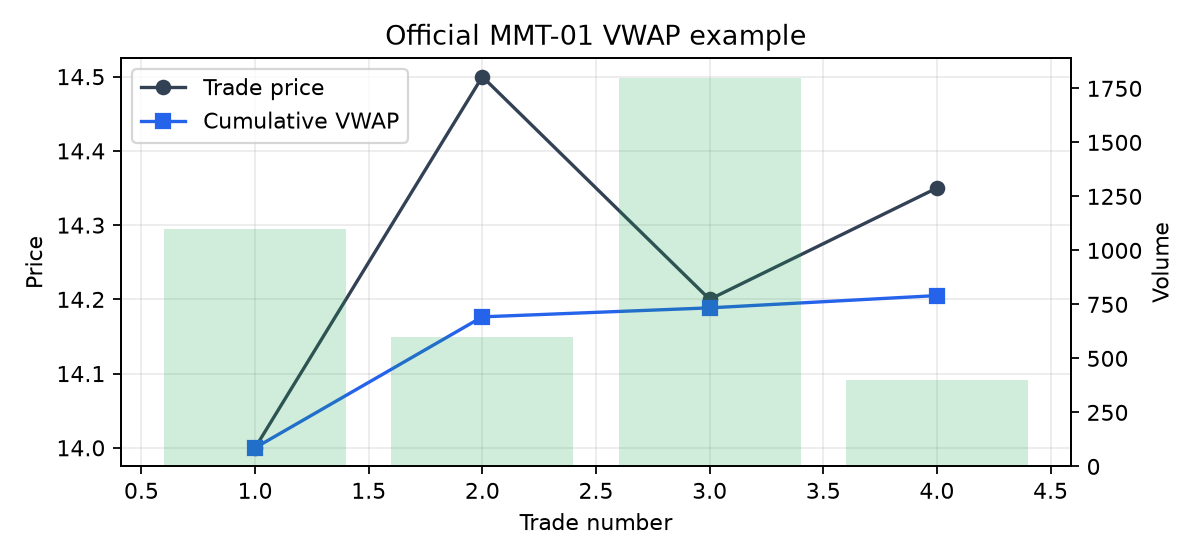

In [7]:
vwap_trades["price_x_volume"] = vwap_trades["price"] * vwap_trades["volume"]
vwap_trades["cum_price_x_volume"] = vwap_trades["price_x_volume"].cumsum()
vwap_trades["cum_volume"] = vwap_trades["volume"].cumsum()
vwap_trades["cum_vwap"] = vwap_trades["cum_price_x_volume"] / vwap_trades["cum_volume"]
vwap = vwap_trades["price_x_volume"].sum() / vwap_trades["volume"].sum()
print(f"VWAP = sum(price x volume) / sum(volume) = {vwap:.3f}")
display(vwap_trades)

fig, ax1 = plt.subplots(figsize=(7.5, 3.5))
ax1.plot(vwap_trades["trade"], vwap_trades["price"], marker="o", color="#334155", label="Trade price")
ax1.plot(vwap_trades["trade"], vwap_trades["cum_vwap"], marker="s", color="#2563eb", label="Cumulative VWAP")
ax1.set_xlabel("Trade number")
ax1.set_ylabel("Price")
ax2 = ax1.twinx()
ax2.bar(vwap_trades["trade"], vwap_trades["volume"], alpha=0.2, color="#16a34a", label="Volume")
ax2.set_ylabel("Volume")
ax1.set_title("Official MMT-01 VWAP example")
ax1.grid(alpha=0.25)
ax1.legend(loc="upper left")
plt.tight_layout()
fig.savefig("chart_addendum_2_vwap.png", dpi=160)
plt.close(fig)
display(Image(filename="chart_addendum_2_vwap.png"))

## Part 7 ? Theoretical and practical time horizon

The slides define a feasibility test for large orders: theoretical time horizon (TTH) divided by practical time horizon (PTH). If the ratio is greater than 2, the order is too large or too urgent for the available liquidity.

In [8]:
def horizon(order_shares, urgency, min_vol_per_min, time_left=120, max_horizon=120):
    vol_ratio = {"High": 0.15, "Medium": 0.075, "Low": 0.025}[urgency]
    theoretical = order_shares / (vol_ratio * min_vol_per_min)
    practical = min(time_left, theoretical, max_horizon)
    ratio = theoretical / practical
    verdict = "ACCEPT" if ratio <= 2 else "BOUNCE / MANUAL REVIEW"
    return pd.Series({
        "order_shares": order_shares,
        "urgency": urgency,
        "vol_ratio": vol_ratio,
        "min_vol_per_min": min_vol_per_min,
        "TTH_min": theoretical,
        "PTH_min": practical,
        "TTH_over_PTH": ratio,
        "verdict": verdict,
    })

horizon_table = pd.DataFrame([
    horizon(10_000, "High", 500),
    horizon(10_000, "Medium", 500),
    horizon(10_000, "Low", 500),
])
display(horizon_table)

,order_shares,urgency,vol_ratio,min_vol_per_min,TTH_min,PTH_min,TTH_over_PTH,verdict
0,10000,High,0.150,500,133.333333,120,1.111111,ACCEPT
1,10000,Medium,0.075,500,266.666667,120,2.222222,BOUNCE / MANUAL REVIEW
2,10000,Low,0.025,500,800.000000,120,6.666667,BOUNCE / MANUAL REVIEW


## Part 8 ? IOC, FOK, iceberg, and pro-rata examples

This cell turns four workbook order-type examples into compact, auditable tables.

In [9]:
order_types = pd.DataFrame([
    {"order_type": "FOK buy 20 @100.10 when only 15 remain", "filled": 0, "cancelled": 20, "reason": "Full quantity unavailable"},
    {"order_type": "IOC buy 20 @100.10 when only 15 remain", "filled": 15, "cancelled": 5, "reason": "Partial fill accepted"},
    {"order_type": "Iceberg sell 100 @100.05, display 10", "filled": 15, "cancelled": 0, "reason": "Displayed tip replenishes from hidden 90"},
])
print("Special order outcomes:")
display(order_types)
print("\nPro-rata allocation for a sell order of 10 shares interacting with 20 eligible bid shares:")
display(pro_rata)

Special order outcomes:


,order_type,filled,cancelled,reason
0,FOK buy 20 @100.10 when only 15 remain,0,20,Full quantity unavailable
1,IOC buy 20 @100.10 when only 15 remain,15,5,Partial fill accepted
2,"Iceberg sell 100 @100.05, display 10",15,0,Displayed tip replenishes from hidden 90



Pro-rata allocation for a sell order of 10 shares interacting with 20 eligible bid shares:


,level,bid_qty,bid_price,eligible_qty,fill_formula,fill_qty
0,1,2,100.0,20,2*10/20,1
1,2,6,99.5,20,6*10/20,3
2,3,12,99.0,20,12*10/20,6


## Part 9 ? Order-flow imbalance proxy

The Cont-Kukanov-Stoikov reading says short-horizon price changes are better explained by order-flow imbalance (OFI) than by raw volume. Because the course pack does not include real tick-by-tick events, this cell uses a deterministic simulated proxy to demonstrate the calculation and chart shape.

Fitted slope = 0.806 ticks per OFI unit; R-squared = 0.842


,ofi_proxy,mid_change_ticks,model_pred
0,1.691,1.394,1.359
1,-0.466,-0.781,-0.379
2,0.033,-0.627,0.023
3,0.408,-0.289,0.325
4,-0.789,-0.485,-0.639
5,0.002,-0.410,-0.002
6,-0.001,0.394,-0.004
7,-1.755,-0.941,-1.417


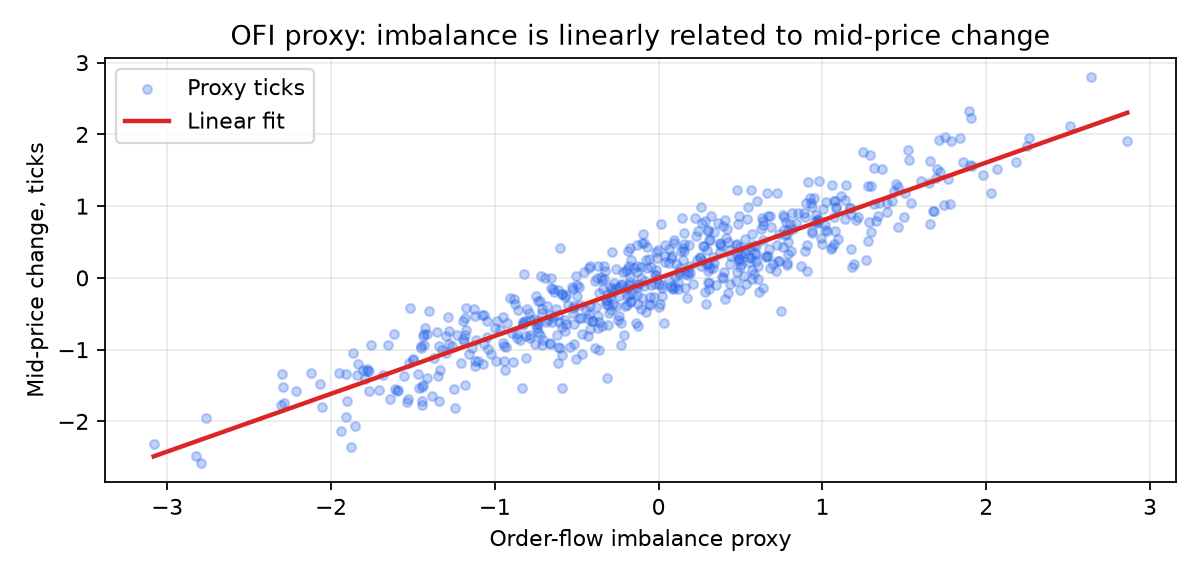

In [10]:
n = 600
ofi = np.random.normal(0, 1.0, n)
noise = np.random.normal(0, 0.35, n)
impact_per_unit = 0.82
mid_change_ticks = impact_per_unit * ofi + noise
coef = np.polyfit(ofi, mid_change_ticks, 1)
pred = np.polyval(coef, ofi)
r2 = 1 - np.sum((mid_change_ticks - pred) ** 2) / np.sum((mid_change_ticks - mid_change_ticks.mean()) ** 2)
ofi_sample = pd.DataFrame({"ofi_proxy": ofi[:8].round(3), "mid_change_ticks": mid_change_ticks[:8].round(3), "model_pred": pred[:8].round(3)})
print(f"Fitted slope = {coef[0]:.3f} ticks per OFI unit; R-squared = {r2:.3f}")
display(ofi_sample)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.scatter(ofi, mid_change_ticks, alpha=0.28, s=16, color="#2563eb", label="Proxy ticks")
xs = np.linspace(ofi.min(), ofi.max(), 100)
ax.plot(xs, np.polyval(coef, xs), color="#dc2626", linewidth=2, label="Linear fit")
ax.set_title("OFI proxy: imbalance is linearly related to mid-price change")
ax.set_xlabel("Order-flow imbalance proxy")
ax.set_ylabel("Mid-price change, ticks")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig("chart_addendum_3_ofi_impact.png", dpi=160)
plt.close(fig)
display(Image(filename="chart_addendum_3_ofi_impact.png"))

## Part 10 ? FAQ checks and execution-risk checklist

The final cell captures the non-code edge cases from the official FAQ so they are visible in the notebook output.

In [11]:
faq_checks = pd.DataFrame([
    {"case": "No buy orders, you send a sell order", "execution_result": "Sell order rests until an opposite buyer arrives, unless order validity cancels it"},
    {"case": "Large buy order, not enough sellers", "execution_result": "Partial fill, rest, or cancel depending on order type; exchange does not take the other side"},
    {"case": "Two market orders seem simultaneous", "execution_result": "Exchange timestamps them and processes one first"},
    {"case": "Need stop loss and profit target", "execution_result": "Use a broker-supported bracket order"},
    {"case": "Only top five levels shown", "execution_result": "That is a retail depth view; full event data is richer"},
])
display(faq_checks)

,case,execution_result
0,"No buy orders, you send a sell order",Sell order rests until an opposite buyer arriv...
1,"Large buy order, not enough sellers","Partial fill, rest, or cancel depending on ord..."
2,Two market orders seem simultaneous,Exchange timestamps them and processes one first
3,Need stop loss and profit target,Use a broker-supported bracket order
4,Only top five levels shown,That is a retail depth view; full event data i...


## Summary

You now have executable examples for the lecture's core mechanics: reading an order book, walking the book, comparing market and marketable limit orders, queue priority, VWAP, time-horizon feasibility, special orders, pro-rata allocation, and the OFI reading's impact idea.